# Lab 01: Vectors, Matrices, Tensors & Their Products

**Reference:** Goodfellow et al. *Deep Learning*, Chapter 2, Sections 2.1–2.2

Read these sections first, then study the code below.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Part 1: Scalars, Vectors, Matrices, and Tensors

*Book reference: Section 2.1*

In [33]:
# Scalars, vectors, matrices, tensors — shape distinctions

# Scalar: a single number
s = np.float64(3.14)
print(f"Scalar:       value={s},  shape={np.shape(s)},  ndim={np.ndim(s)}")

# 1D array: NumPy’s default — neither row nor column
v_1d = np.array([1.0, 2.0, 3.0])
print(f"1D array:     {v_1d},  shape={v_1d.shape},  ndim={v_1d.ndim}")

# Column vector: shape (n, 1)
v_col = v_1d.reshape(-1, 1)
print(f"Column vec:   shape={v_col.shape},  ndim={v_col.ndim}")
print(f"  contents:\n{v_col}")

# Row vector: shape (1, n)
v_row = v_1d.reshape(1, -1)
print(f"Row vec:      shape={v_row.shape},  ndim={v_row.ndim}")
print(f"  contents: {v_row}")

# Matrix: shape (m, n)
M = np.arange(1, 13).reshape(3, 4)
print(f"\nMatrix (3×4):\n{M}")

# 3-D tensor: shape (batch, rows, cols)
T = np.arange(24).reshape(2, 3, 4)
print(f"\n3-D tensor shape: {T.shape}")
print(f"First 'slice' (T[0]):\n{T[0]}")

Scalar:       value=3.14,  shape=(),  ndim=0
1D array:     [1. 2. 3.],  shape=(3,),  ndim=1
Column vec:   shape=(3, 1),  ndim=2
  contents:
[[1.]
 [2.]
 [3.]]
Row vec:      shape=(1, 3),  ndim=2
  contents: [[1. 2. 3.]]

Matrix (3×4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

3-D tensor shape: (2, 3, 4)
First 'slice' (T[0]):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [34]:
# Broadcasting — how shapes interact in operations

print("--- Broadcasting examples ---")
print(f"v_1d + v_1d   shape: {(v_1d + v_1d).shape}   ← element-wise, same shape")
print(f"v_col + v_row shape: {(v_col + v_row).shape}  ← (3,1)+(1,3) broadcasts to (3,3) outer-sum")
print()

# Matrix-vector product with @
print(f"M shape: {M.shape}")
print(f"v_1d shape: {v_1d.shape}")
print(f"v_1d @ M      shape: {(v_1d @ M).shape}      ← (3,) @ (3,4) = (4,)  [1D acts as row on left]")
print(f"v_col.T @ M   shape: {(v_col.T @ M).shape}   ← (1,3) @ (3,4) = (1,4) [explicit row vector]")
print()

# The outer-sum from broadcasting
outer_sum = v_col + v_row
print(f"v_col + v_row =\n{outer_sum}")
print("Each element [i,j] = v[i] + v[j]")

--- Broadcasting examples ---
v_1d + v_1d   shape: (3,)   ← element-wise, same shape
v_col + v_row shape: (3, 3)  ← (3,1)+(1,3) broadcasts to (3,3) outer-sum

M shape: (3, 4)
v_1d shape: (3,)
v_1d @ M      shape: (4,)      ← (3,) @ (3,4) = (4,)  [1D acts as row on left]
v_col.T @ M   shape: (1, 4)   ← (1,3) @ (3,4) = (1,4) [explicit row vector]

v_col + v_row =
[[2. 3. 4.]
 [3. 4. 5.]
 [4. 5. 6.]]
Each element [i,j] = v[i] + v[j]


### Exercise 1: Reshape Drill

Given a flat array of 24 elements, find all valid 2D matrix shapes.

In [35]:
# Exercise 1: Find all (rows, cols) pairs where rows * cols == 24

a = np.arange(24)

# Find all divisors of 24 and pair them
all_shapes = [(r, 24 // r) for r in range(1, 25) if 24 % r == 0]

# Verify each shape works
for r, c in all_shapes:
    reshaped = a.reshape(r, c)
    assert reshaped.shape == (r, c)

print(f"All {len(all_shapes)} valid shapes for 24 elements:")
for r, c in all_shapes:
    print(f"  ({r:2d}, {c:2d})  →  {a.reshape(r, c).shape}")

All 8 valid shapes for 24 elements:
  ( 1, 24)  →  (1, 24)
  ( 2, 12)  →  (2, 12)
  ( 3,  8)  →  (3, 8)
  ( 4,  6)  →  (4, 6)
  ( 6,  4)  →  (6, 4)
  ( 8,  3)  →  (8, 3)
  (12,  2)  →  (12, 2)
  (24,  1)  →  (24, 1)


### Exercise 2: Tensor Indexing

Create a 3D tensor and practice extracting slices.

In [36]:
# Exercise 2: Tensor slicing on shape (3, 4, 5)
# Think of it as a batch of 3 matrices, each 4 rows × 5 columns.

T = np.arange(60).reshape(3, 4, 5)
print(f"T shape: {T.shape}\n")

# (a) Extract the second matrix (index 1)
second_matrix = T[1]
print(f"(a) T[1] shape: {second_matrix.shape}")
print(f"{second_matrix}\n")

# (b) First row of EVERY matrix
first_rows = T[:, 0, :]
print(f"(b) T[:, 0, :] shape: {first_rows.shape}")
print(f"{first_rows}\n")

# (c) Main diagonal of each matrix — advanced integer indexing
# For each batch i, we want elements T[i, 0, 0], T[i, 1, 1], T[i, 2, 2], T[i, 3, 3]
diag_idx = np.arange(4)
diagonals = T[:, diag_idx, diag_idx]   # shape (3, 4)
print(f"(c) diagonals shape: {diagonals.shape}")
print(f"{diagonals}")

# Verify
assert second_matrix.shape == (4, 5)
assert first_rows.shape == (3, 5)
assert diagonals.shape == (3, 4)
for i in range(3):
    for j in range(4):
        assert diagonals[i, j] == T[i, j, j]
print("\nAll checks passed.")

T shape: (3, 4, 5)

(a) T[1] shape: (4, 5)
[[20 21 22 23 24]
 [25 26 27 28 29]
 [30 31 32 33 34]
 [35 36 37 38 39]]

(b) T[:, 0, :] shape: (3, 5)
[[ 0  1  2  3  4]
 [20 21 22 23 24]
 [40 41 42 43 44]]

(c) diagonals shape: (3, 4)
[[ 0  6 12 18]
 [20 26 32 38]
 [40 46 52 58]]

All checks passed.


## Part 2: Matrix-Vector Products

*Book reference: Section 2.2 — “We can think of the product Ax as computing a linear combination of the columns of A.”*

A = 
[[ 2. -1.]
 [ 1.  2.]]
x = [1.5 1. ]
col0 = [2. 1.],  col1 = [-1.  2.]
Ax = 1.5*[2. 1.] + 1.0*[-1.  2.] = [3.  1.5] + [-1.  2.] = [2.  3.5]



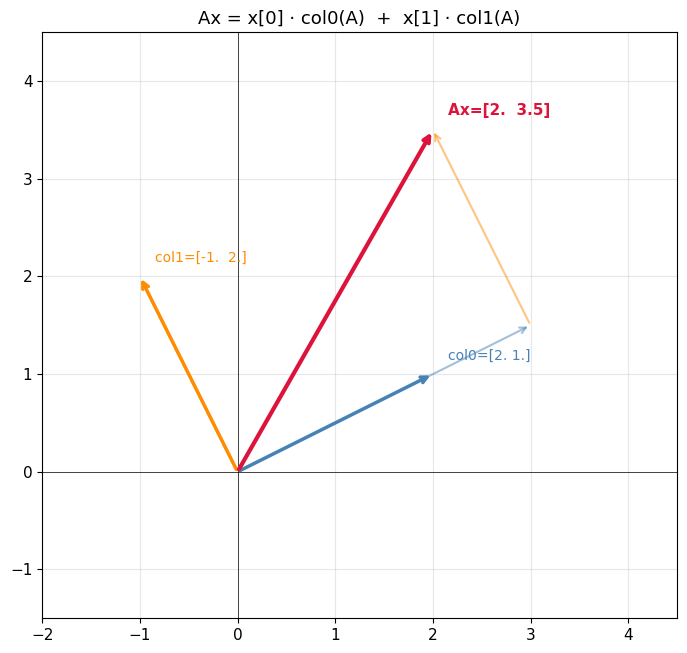

In [37]:
# Demo: Ax as a linear combination of columns of A
#
# If A has columns [a_0, a_1] and x = [x_0, x_1], then:
#   Ax = x_0 * a_0 + x_1 * a_1

A = np.array([[2.0, -1.0],
              [1.0,  2.0]])
x = np.array([1.5, 1.0])

col0 = A[:, 0]   # first column
col1 = A[:, 1]   # second column
Ax   = A @ x     # the product

sc0 = x[0] * col0   # scaled first column
sc1 = x[1] * col1   # scaled second column

print(f"A = \n{A}")
print(f"x = {x}")
print(f"col0 = {col0},  col1 = {col1}")
print(f"Ax = {x[0]}*{col0} + {x[1]}*{col1} = {sc0} + {sc1} = {Ax}")
print()

# Visualize
fig, ax = plt.subplots(figsize=(7, 7))
o = [0, 0]  # origin

# Draw the two columns of A
ax.annotate('', xy=col0, xytext=o,
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.annotate('', xy=col1, xytext=o,
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.5))

# Draw scaled columns (head-to-tail to show the sum)
ax.annotate('', xy=sc0, xytext=o,
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5, alpha=0.5))
ax.annotate('', xy=sc0 + sc1, xytext=sc0,
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.5, alpha=0.5))

# Draw the result Ax
ax.annotate('', xy=Ax, xytext=o,
            arrowprops=dict(arrowstyle='->', color='crimson', lw=3))

# Labels
offset = 0.15
ax.text(col0[0]+offset, col0[1]+offset, f'col0={col0}', color='steelblue', fontsize=10)
ax.text(col1[0]+offset, col1[1]+offset, f'col1={col1}', color='darkorange', fontsize=10)
ax.text(Ax[0]+offset, Ax[1]+offset, f'Ax={Ax}', color='crimson', fontsize=11, fontweight='bold')

ax.set_xlim(-2, 4.5)
ax.set_ylim(-1.5, 4.5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Ax = x[0] · col0(A)  +  x[1] · col1(A)', fontsize=13)
plt.tight_layout()
plt.show()

### Exercise 3: Matrix-Vector Product from Scratch

Implement using only loops and scalar operations — to see exactly what `A @ x` does.

In [38]:
# Exercise 3: Matrix-vector product with explicit loops

def matrix_vector_product(A, x):
    """Compute A @ x using only loops and scalar multiply/add.
    A: (m, n),  x: (n,)  →  result: (m,)
    """
    m, n = A.shape
    result = np.zeros(m)
    for i in range(m):          # for each row of A
        for j in range(n):      # dot product: row i of A with x
            result[i] += A[i, j] * x[j]
    return result

# Test
A_test = np.random.randn(4, 3)
x_test = np.random.randn(3)

ours    = matrix_vector_product(A_test, x_test)
builtin = A_test @ x_test

print(f"Our result:    {ours}")
print(f"NumPy result:  {builtin}")
assert np.allclose(ours, builtin)
print("\nMatch! ✔")

Our result:    [-0.73248507  1.2203838  -0.27640305  1.82127253]
NumPy result:  [-0.73248507  1.2203838  -0.27640305  1.82127253]

Match! ✔


### Exercise 4: Matrix Multiply — Three Interpretations

The product C = AB can be viewed three different ways. All produce the same result.

In [39]:
# Exercise 4: Three ways to compute C = A @ B

def matmul_row_col(A, B):
    """View 1: C[i,j] = dot(row i of A, column j of B)"""
    m, n = A.shape
    p = B.shape[1]
    C = np.zeros((m, p))
    for i in range(m):
        for j in range(p):
            C[i, j] = np.dot(A[i, :], B[:, j])
    return C

def matmul_column_wise(A, B):
    """View 2: Each column of C is A times the corresponding column of B.
    C[:, j] = A @ B[:, j]"""
    m = A.shape[0]
    p = B.shape[1]
    C = np.zeros((m, p))
    for j in range(p):
        C[:, j] = A @ B[:, j]
    return C

def matmul_outer_product(A, B):
    """View 3: C = sum of rank-1 outer products.
    C = sum_k  outer(A[:, k], B[k, :])"""
    m, n = A.shape
    p = B.shape[1]
    C = np.zeros((m, p))
    for k in range(n):
        C += np.outer(A[:, k], B[k, :])   # rank-1 matrix
    return C

# Test all three on the same inputs
A = np.random.randn(4, 3)
B = np.random.randn(3, 5)
expected = A @ B

for name, fn in [("row-col", matmul_row_col),
                 ("column-wise", matmul_column_wise),
                 ("outer-product", matmul_outer_product)]:
    result = fn(A, B)
    assert np.allclose(result, expected), f"{name} failed!"
    print(f"matmul {name:>14s}: PASSED")

matmul        row-col: PASSED
matmul    column-wise: PASSED
matmul  outer-product: PASSED


### Exercise 5: Batch Matrix Multiply

When you have a batch (stack) of matrices, multiply each pair independently.

In [40]:
# Exercise 5: Batch matmul for 3D tensors

def batch_matmul(A, B):
    """A: (batch, m, n), B: (batch, n, p) → C: (batch, m, p)
    C[i] = A[i] @ B[i]  for each element in the batch."""
    batch_size = A.shape[0]
    C = np.zeros((batch_size, A.shape[1], B.shape[2]))
    for i in range(batch_size):
        C[i] = A[i] @ B[i]
    return C

# Test
A = np.random.randn(8, 4, 3)
B = np.random.randn(8, 3, 5)

ours    = batch_matmul(A, B)
builtin = np.einsum('bij,bjk->bik', A, B)

assert np.allclose(ours, builtin)
print(f"batch_matmul: PASSED  (output shape {ours.shape})")

batch_matmul: PASSED  (output shape (8, 4, 5))


## Part 3: Visualizing Linear Transformations

*A matrix can be thought of as a function that maps vectors. In 2D, we can see this by watching how a matrix transforms the unit circle.*

Rotation matrix (30°):
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]
R is orthogonal: R^T R = I? True
det(R) = 1.0000  (should be +1 for rotation)



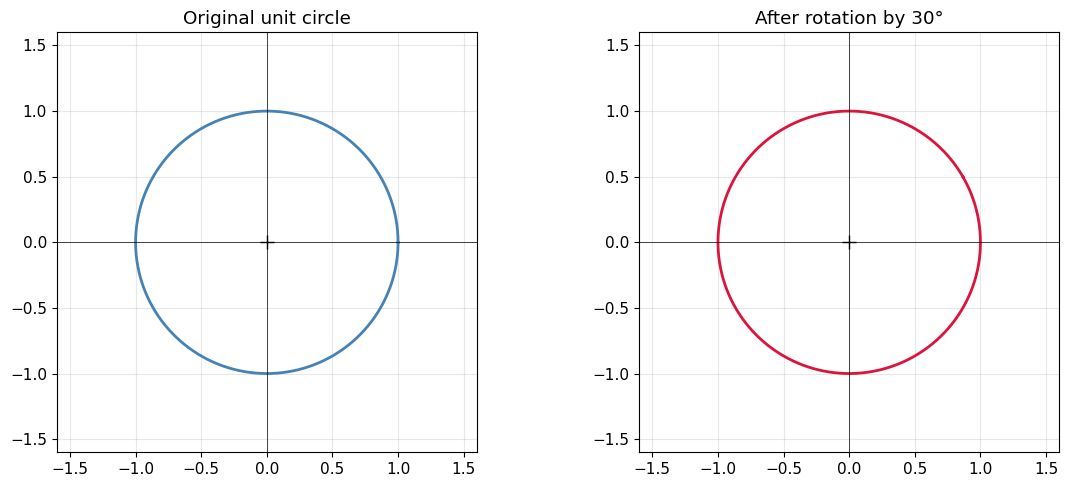

In [41]:
# Demo: A rotation matrix transforms the unit circle into... a rotated circle

theta_rot = np.pi / 6   # 30 degrees
R = np.array([[np.cos(theta_rot), -np.sin(theta_rot)],
              [np.sin(theta_rot),  np.cos(theta_rot)]])

print(f"Rotation matrix (30°):\n{np.round(R, 4)}")
print(f"R is orthogonal: R^T R = I? {np.allclose(R.T @ R, np.eye(2))}")
print(f"det(R) = {np.linalg.det(R):.4f}  (should be +1 for rotation)")
print()

# Points on the unit circle
t = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(t), np.sin(t)])       # (2, 300)
rotated = R @ circle                             # (2, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pts, title, color in [
    (axes[0], circle,  'Original unit circle', 'steelblue'),
    (axes[1], rotated, 'After rotation by 30°', 'crimson')]:
    ax.plot(pts[0], pts[1], color=color, lw=2)
    ax.plot(0, 0, 'k+', ms=10)
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Exercise 6: Linear Transformation Gallery

Four fundamental 2×2 transformations and what they do to the unit circle.

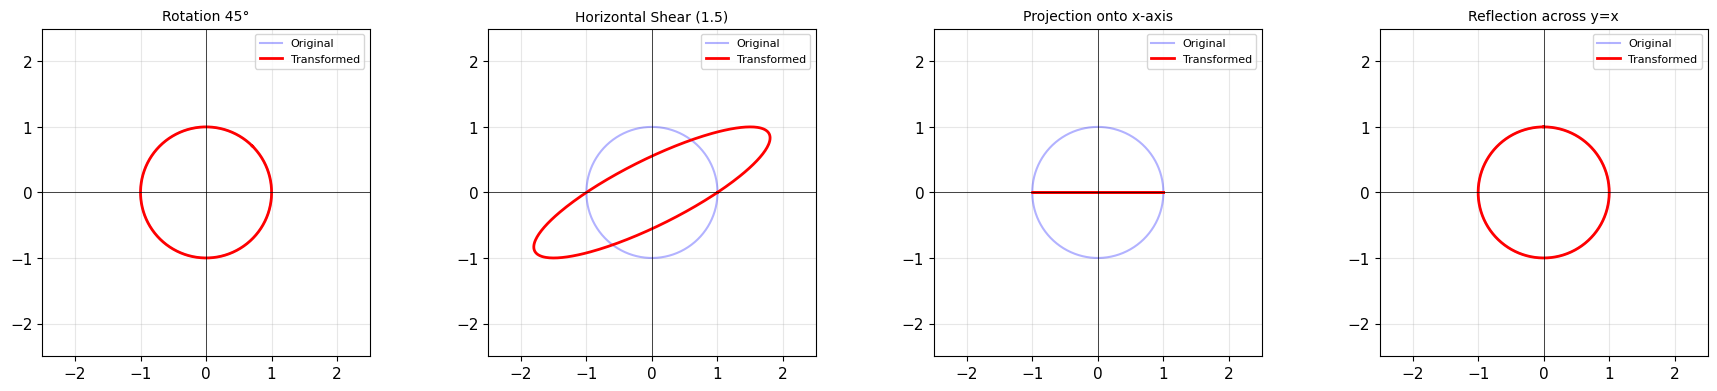

      R_45:  det=+1.000,  rank=2
     Shear:  det=+1.000,  rank=2
      Proj:  det=+0.000,  rank=1
   Reflect:  det=-1.000,  rank=2


In [42]:
# Exercise 6: Build four 2x2 matrices and visualize

# (a) Rotation by 45 degrees
angle = np.pi / 4
R_45 = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])

# (b) Horizontal shear with factor 1.5
#     Shear maps [x, y] → [x + 1.5*y, y]
Shear = np.array([[1.0, 1.5],
                   [0.0, 1.0]])

# (c) Projection onto the x-axis
#     Kills the y-component entirely
Proj = np.array([[1.0, 0.0],
                  [0.0, 0.0]])

# (d) Reflection across the line y = x
#     Swaps x and y coordinates
Reflect = np.array([[0.0, 1.0],
                     [1.0, 0.0]])

# Visualize all four
t = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(t), np.sin(t)])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, M, title in zip(axes,
                        [R_45, Shear, Proj, Reflect],
                        ['Rotation 45°', 'Horizontal Shear (1.5)',
                         'Projection onto x-axis', 'Reflection across y=x']):
    transformed = M @ circle
    ax.plot(circle[0], circle[1], 'b-', alpha=0.3, label='Original')
    ax.plot(transformed[0], transformed[1], 'r-', lw=2, label='Transformed')
    ax.set_aspect('equal')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Print properties
for name, M in [('R_45', R_45), ('Shear', Shear), ('Proj', Proj), ('Reflect', Reflect)]:
    print(f"{name:>10s}:  det={np.linalg.det(M):+.3f},  rank={np.linalg.matrix_rank(M)}")

### Exercise 7: Hadamard and Kronecker Products

Two matrix products beyond the standard `@`:
- **Hadamard** (element-wise): same-shape matrices, multiply entry by entry.
- **Kronecker**: each scalar A[i,j] gets replaced by the block A[i,j]*B.

In [43]:
# Exercise 7: Hadamard and Kronecker products from scratch

def hadamard_product(A, B):
    """Element-wise product using explicit loops (not A * B)."""
    m, n = A.shape
    C = np.zeros_like(A, dtype=float)
    for i in range(m):
        for j in range(n):
            C[i, j] = A[i, j] * B[i, j]
    return C

def kronecker_product(A, B):
    """Kronecker product: (m,n) ⊗ (p,q) → (m*p, n*q).
    Block (i,j) of the result is A[i,j] * B."""
    m, n = A.shape
    p, q = B.shape
    C = np.zeros((m * p, n * q))
    for i in range(m):
        for j in range(n):
            C[i*p:(i+1)*p, j*q:(j+1)*q] = A[i, j] * B
    return C

# Test
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# Hadamard
h = hadamard_product(A, B)
assert np.allclose(h, A * B)
print(f"Hadamard product (element-wise):")
print(f"  A = {A.tolist()}")
print(f"  B = {B.tolist()}")
print(f"  A ⊙ B = {h.tolist()}")
print()

# Kronecker
k = kronecker_product(A, B)
assert k.shape == (4, 4)
assert np.allclose(k, np.kron(A, B))
print(f"Kronecker product (2×2 ⊗ 2×2 = 4×4):")
print(k.astype(int))

Hadamard product (element-wise):
  A = [[1, 2], [3, 4]]
  B = [[5, 6], [7, 8]]
  A ⊙ B = [[5.0, 12.0], [21.0, 32.0]]

Kronecker product (2×2 ⊗ 2×2 = 4×4):
[[ 5  6 10 12]
 [ 7  8 14 16]
 [15 18 20 24]
 [21 24 28 32]]


## Summary

Concepts covered in this lab:
- **Shapes:** scalar (0D), vector (1D), matrix (2D), tensor (3D+)
- **Broadcasting:** how NumPy handles mismatched shapes
- **Matrix-vector product** as a linear combination of columns
- **Matrix multiply** three ways: row-col dots, column-wise, outer-product sum
- **Batch operations** over stacks of matrices
- **Linear transformations:** rotation, shear, projection, reflection
- **Hadamard** (element-wise) and **Kronecker** (block) products

**Next:** Lab 02 — Inverses, Linear Systems & Span (Sections 2.3–2.4)